# Import

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
plt.rcParams['font.family'] = 'serif'

In [3]:
# Usage
base_dir = "../experiment15[depol-time-evo-noisy_tmax_20_various_p]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)
EXACT_SOL: float = -8.566772233505624

In [4]:
RAW_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'VQE_noiseoff', 'p1e-5'])

In [5]:
RAW_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'VQE_noiseoff', 'p1e-5'])

In [6]:
def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}
        
        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noiseoff", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue
        
        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (mul1, ric2, etc.) ---
        zne_folder = content.get("ZNE", {})
        
        # If mul1 is missing, ensure the key exists in the raw zne_folder
        for label, runs in zne_folder.items():
            ext_vals, all_y_curves = [], []
            noise_levels = None
            
            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run: 
                    continue
                
                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})
                
                tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                p_list = run["config"]["noise_profile"]["noise_prob"]
                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                if current_y and current_n and ext_val is not None:
                    ext_vals.append(ext_val)
                    all_y_curves.append(current_y)
                    if noise_levels is None:
                        noise_levels = current_n
                else:
                    # Debug print to see which file is failing the check
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing", 
                    "tmax":           tmax,
                    "delp":           p_list[2],
                    "exact_sol":      EXACT_SOL, # Global variable
                    "oder":           len(noise_levels)-1,
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"]
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [7]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

dict_keys(['p1e-4', 'p1e-1', 'p1e-3', 'p1e-2', 'VQE_noiseoff', 'p1e-5'])

In [8]:
PROCESSED_SIM_DATA["p1e-3"]

{'ric6': {'noise_type': 'depolarizing',
  'tmax': 20,
  'delp': 0.001,
  'exact_sol': -8.566772233505624,
  'oder': 5,
  'sorted_noise': [7, 21, 35, 49, 63, 77],
  'mean_exp_vals': [-7.692441253579726,
   -6.344485917465554,
   -5.246090641165405,
   -4.349031501638546,
   -3.614718350280924,
   -3.012219352595078],
  'std_exp_vals': [0.06703936431520066,
   0.13368361755219485,
   0.1788299605044942,
   0.20551572739313026,
   0.21862509673318598,
   0.22207917113521555],
  'zne_mean': -8.478194303655439,
  'zne_std': 0.039458574671303676,
  'mean_noise_off': None,
  'std_noise_off': None},
 'ric7': {'noise_type': 'depolarizing',
  'tmax': 20,
  'delp': 0.001,
  'exact_sol': -8.566772233505624,
  'oder': 6,
  'sorted_noise': [7, 21, 35, 49, 63, 77, 91],
  'mean_exp_vals': [-7.692441253579726,
   -6.344485917465552,
   -5.246090641165404,
   -4.349031501638547,
   -3.614718350280925,
   -3.0122193525950776,
   -2.5166991277102304],
  'std_exp_vals': [0.06703936431520066,
   0.133683617

---

## 4-point ZNE for various T_max values

In [9]:
width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "../master-reports/"

In [10]:
def plot_zne_vs_delp(
    data: dict,
    rics: list[str],
    title: str = None,
    figsize: tuple = (7, 4.5),
    save_dir: str = "reports",
    file_type: str = "png",
    file_name: str = "zne_vs_delp",
    dpi: int = 600,
):
    fig = plt.figure(figsize=figsize, dpi=dpi, layout="constrained")
    ax = fig.add_subplot(111)

    cmap = plt.get_cmap("tab10")

    def p_sort_key(p_key):
        try:
            return float(p_key.replace("p", "").replace("e", "e"))
        except ValueError:
            return float("inf")

    p_keys = sorted(
        [k for k in data if k.startswith("p1e")],
        key=p_sort_key,
    )

    exact_sol = None

    for idx, ric in enumerate(rics):
        delp_vals, zne_means, zne_stds = [], [], []

        for p_key in p_keys:
            if ric not in data[p_key]:
                continue
            entry = data[p_key][ric]
            delp_vals.append(entry["delp"])
            zne_means.append(entry["zne_mean"])
            zne_stds.append(entry["zne_std"])

            if exact_sol is None:
                exact_sol = entry["exact_sol"]

        if not delp_vals:
            print(f"Warning: {ric} not found in any p: {p_key} key, skipping.")
            continue

        delp_vals = np.array(delp_vals)
        zne_means = np.array(zne_means)
        zne_stds  = np.array(zne_stds)
        color     = cmap(idx)

        ax.errorbar(
            delp_vals, zne_means,
            yerr=zne_stds,
            fmt="o-",
            capsize=4,
            capthick=1.2,
            linewidth=1.6,
            markersize=5,
            color=color,
            ecolor=(*color[:3], 1.0),
            elinewidth=1.5,
            label=ric,
        )

    if exact_sol is not None:
        ax.axhline(
            exact_sol,
            color="#dc2626",
            linewidth=1.6,
            linestyle="--",
            label=f"Exact ({exact_sol:.4f})",
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$p_{\text{T}}$", fontsize=8)
    ax.set_ylabel("ZNE", fontsize=8)
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, linestyle="--")

    os.makedirs(save_dir, exist_ok=True)
    file_type = file_type.lower().lstrip(".")
    out_path  = os.path.join(save_dir, f"{file_name}.{file_type}")

    fig.savefig(out_path, dpi=dpi, bbox_inches=None)

    print(f"Saved → {out_path}")
    plt.show()

In [11]:
PROCESSED_SIM_DATA["p1e-1"].keys()

dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

Saved → ../master-reports/RESULT-ZNE-VS-DELP-IEEE.png


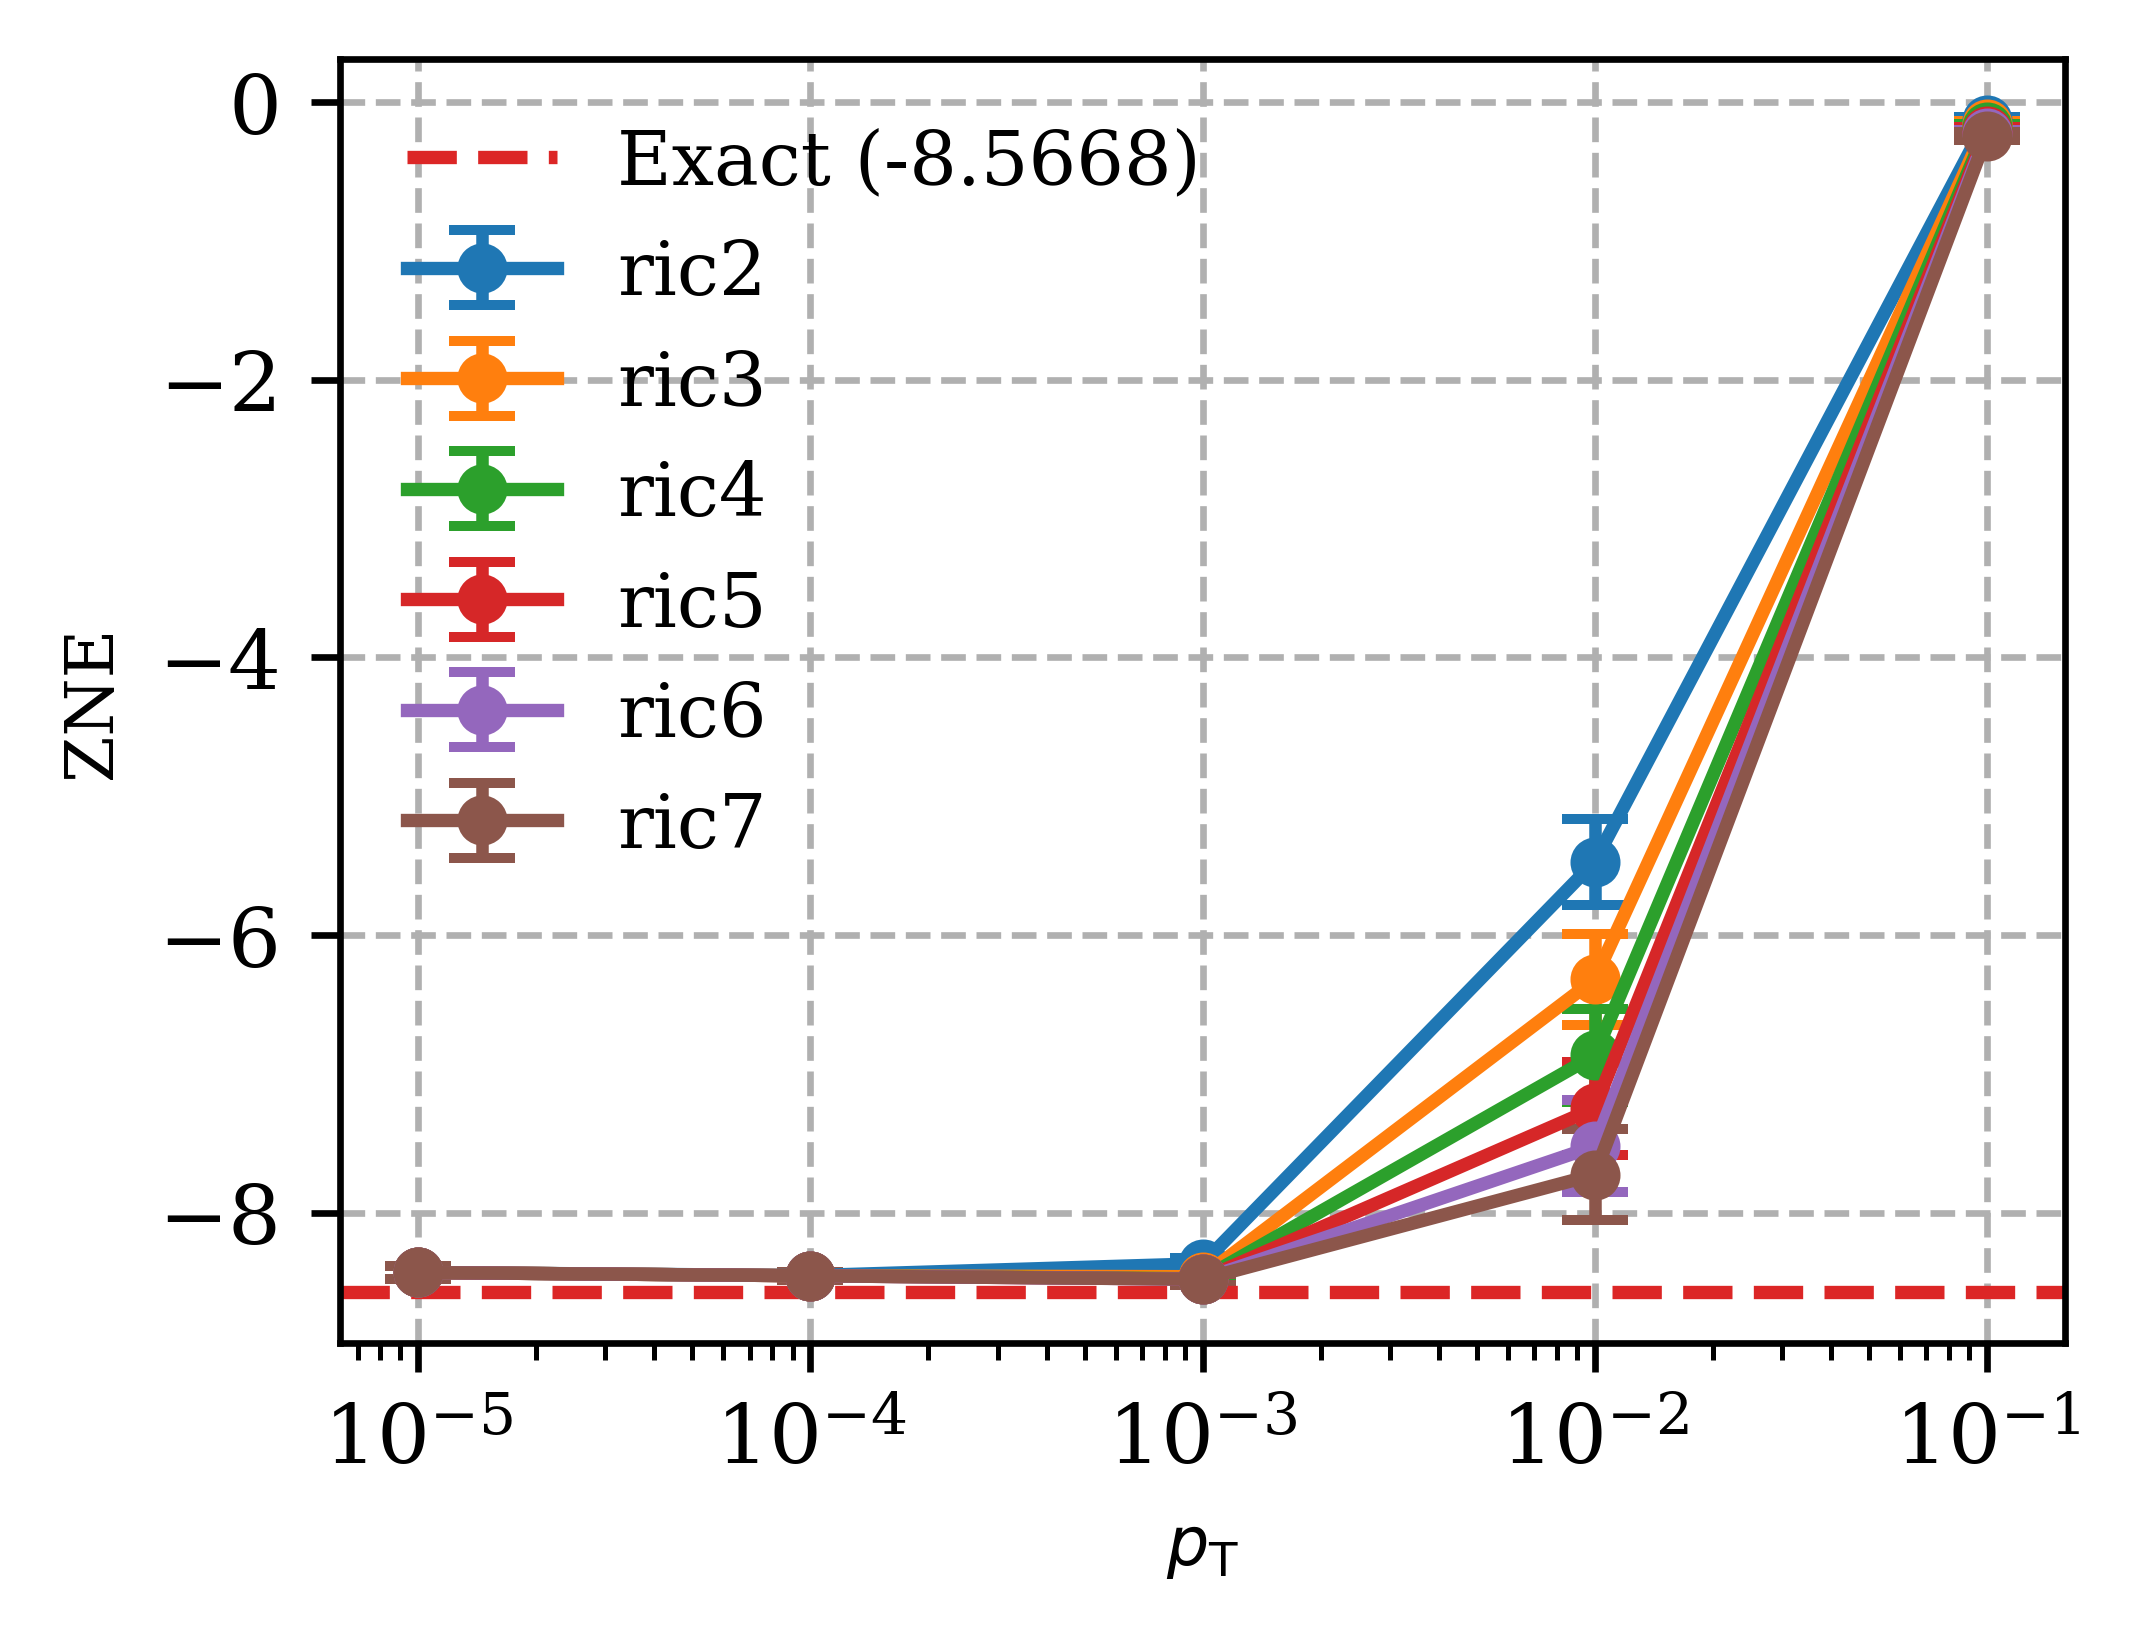

In [12]:
plot_zne_vs_delp(
    PROCESSED_SIM_DATA,
    rics=["ric2", "ric3", "ric4", "ric5", "ric6", "ric7"],
    #title="ZNE vs delp",
    file_name="RESULT-ZNE-VS-DELP-IEEE",
    figsize=FIG_SIZE_IEEE_DOUBLE,
    file_type="png",
    dpi=600,
    save_dir=MASTER_EXPORT_DIR
)